In [1]:
!pip install kagglehub[pandas-dataset]

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "public_transport_delays.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "khushikyad001/public-transport-delays-with-weather-and-events",
  file_path
)

df.head()

/tmp/ipykernel_17062/3381519461.py:6: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 261k/261k [00:00<00:00, 337kB/s]


,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,NaN,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,NaN,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,NaN,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,NaN,500,46,0,0,6,Spring,1


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   trip_id                     2000 non-null   object 
 1   date                        2000 non-null   object 
 2   time                        2000 non-null   object 
 3   transport_type              2000 non-null   object 
 4   route_id                    2000 non-null   object 
 5   origin_station              2000 non-null   object 
 6   destination_station         2000 non-null   object 
 7   scheduled_departure         2000 non-null   object 
 8   scheduled_arrival           2000 non-null   object 
 9   actual_departure_delay_min  2000 non-null   int64  
 10  actual_arrival_delay_min    2000 non-null   int64  
 11  weather_condition           2000 non-null   object 
 12  temperature_C               2000 non-null   float64
 13  humidity_percent            2000 

In [6]:
df.isnull().sum()

,0
trip_id,0
date,0
time,0
transport_type,0
route_id,0
origin_station,0
destination_station,0
scheduled_departure,0
scheduled_arrival,0
actual_departure_delay_min,0


In [10]:
df.columns

Index(['trip_id', 'date', 'time', 'transport_type', 'route_id',
       'origin_station', 'destination_station', 'scheduled_departure',
       'scheduled_arrival', 'actual_departure_delay_min',
       'actual_arrival_delay_min', 'weather_condition', 'temperature_C',
       'humidity_percent', 'wind_speed_kmh', 'precipitation_mm', 'event_type',
       'event_attendance_est', 'traffic_congestion_index', 'holiday',
       'peak_hour', 'weekday', 'season', 'delayed'],
      dtype='object')

In [7]:
df.describe()

,actual_departure_delay_min,actual_arrival_delay_min,temperature_C,humidity_percent,wind_speed_kmh,precipitation_mm,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,delayed
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.688000,13.318000,15.121350,64.714000,29.300500,9.860700,6420.250000,50.244000,0.089500,0.272000,2.976000,0.749500
std,6.268118,9.289727,11.479424,20.334747,17.264015,5.781373,15198.306129,29.225751,0.285535,0.445101,1.990328,0.433409
min,-2.000000,-3.000000,-5.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,5.000000,5.100000,46.000000,15.000000,4.900000,0.000000,25.000000,0.000000,0.000000,1.000000,0.000000
50%,9.000000,13.000000,15.300000,65.000000,29.000000,9.700000,0.000000,50.000000,0.000000,0.000000,3.000000,1.000000
75%,14.000000,21.000000,24.800000,83.000000,45.000000,14.800000,2000.000000,76.000000,0.000000,1.000000,5.000000,1.000000
max,19.000000,29.000000,35.000000,99.000000,59.000000,20.000000,50000.000000,99.000000,1.000000,1.000000,6.000000,1.000000


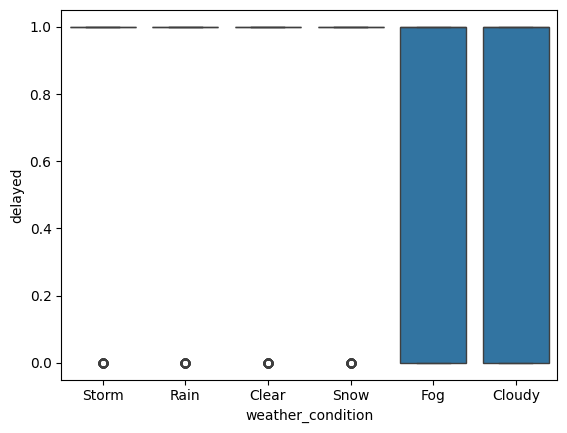

In [9]:
sns.boxplot(x='weather_condition', y='delayed', data=df)
plt.show()

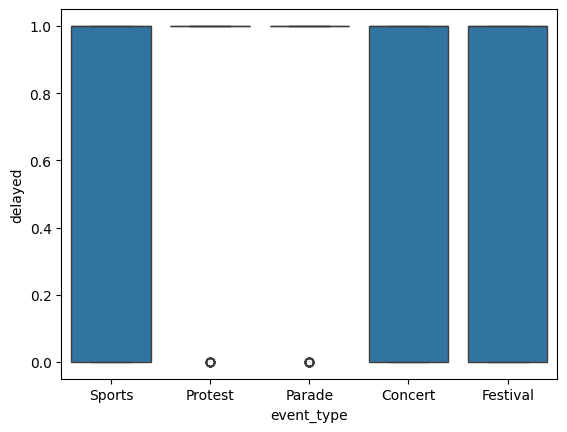

In [11]:
sns.boxplot(x='event_type', y='delayed', data=df)
plt.show()

In [12]:
df.isnull().sum()

,0
trip_id,0
date,0
time,0
transport_type,0
route_id,0
origin_station,0
destination_station,0
scheduled_departure,0
scheduled_arrival,0
actual_departure_delay_min,0


In [13]:
df['event_type'] = df['event_type'].fillna('No Event')

In [14]:
df['event_type'].value_counts()

,count
event_type,
No Event,1173
Festival,221
Sports,212
Concert,203
Parade,105
Protest,86


In [15]:
df.columns = df.columns.str.lower().str.replace(" ", "_")
df.head()

,trip_id,date,time,transport_type,route_id,origin_station,destination_station,scheduled_departure,scheduled_arrival,actual_departure_delay_min,...,wind_speed_kmh,precipitation_mm,event_type,event_attendance_est,traffic_congestion_index,holiday,peak_hour,weekday,season,delayed
0,T00000,2023-01-01,05:00:00,Tram,Route_15,Station_31,Station_6,05:02:00,05:55:00,12,...,46,13.0,No Event,500,81,0,1,6,Winter,0
1,T00001,2023-01-01,05:15:00,Metro,Route_12,Station_49,Station_32,05:16:00,05:55:00,15,...,11,11.4,No Event,0,53,0,0,6,Autumn,1
2,T00002,2023-01-01,05:30:00,Bus,Route_16,Station_29,Station_42,05:33:00,06:17:00,0,...,31,14.1,Sports,0,67,1,0,6,Autumn,0
3,T00003,2023-01-01,05:45:00,Tram,Route_19,Station_26,Station_18,05:49:00,06:08:00,15,...,41,6.4,No Event,500,84,0,0,6,Winter,1
4,T00004,2023-01-01,06:00:00,Tram,Route_8,Station_18,Station_15,06:00:00,06:35:00,-1,...,30,18.5,No Event,500,46,0,0,6,Spring,1


In [18]:
df.groupby('season')['delayed'].mean().sort_values(ascending=False)

,delayed
season,
Winter,0.763158
Autumn,0.756250
Spring,0.749004
Summer,0.730916


In [19]:
df.groupby('event_type')['delayed'].mean()

,delayed
event_type,
Concert,0.733990
Festival,0.746606
No Event,0.755328
Parade,0.761905
Protest,0.767442
Sports,0.721698


In [23]:
df['delayed'].describe()

,delayed
count,2000.000000
mean,0.749500
std,0.433409
min,0.000000
25%,0.000000
50%,1.000000
75%,1.000000
max,1.000000


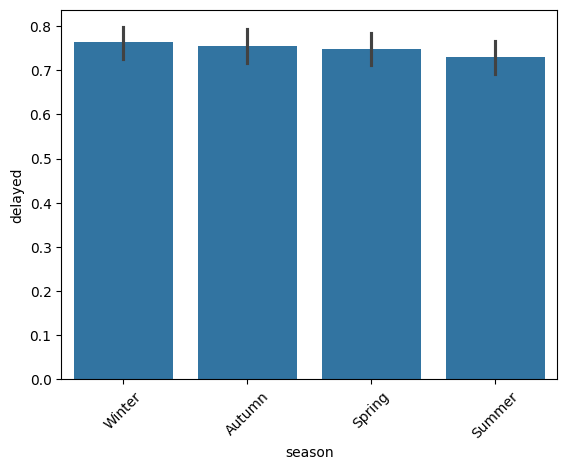

In [21]:
sns.barplot(x='season', y='delayed', data=df)
plt.xticks(rotation=45)
plt.show()

In [25]:
y = df['delayed']

In [26]:
X = df[['season', 'event_type', 'transport_type']]

In [27]:
X =pd.get_dummies(X, drop_first=True)

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [30]:
y_pred = model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.735
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       106
           1       0.73      1.00      0.85       294

    accuracy                           0.73       400
   macro avg       0.37      0.50      0.42       400
weighted avg       0.54      0.73      0.62       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [32]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced')

In [33]:
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.515
              precision    recall  f1-score   support

           0       0.29      0.57      0.38       106
           1       0.76      0.50      0.60       294

    accuracy                           0.52       400
   macro avg       0.52      0.53      0.49       400
weighted avg       0.64      0.52      0.54       400



In [35]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7225
              precision    recall  f1-score   support

           0       0.31      0.04      0.07       106
           1       0.74      0.97      0.84       294

    accuracy                           0.72       400
   macro avg       0.52      0.50      0.45       400
weighted avg       0.62      0.72      0.63       400

